# Part I: Linear Regression with One Feature - Stellar Luminosity

## Objective
Model stellar luminosity as a function of stellar mass using linear regression with an explicit bias term: L_hat = w * M + b

## 1. Setup

In [2]:
%pip install numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
np.set_printoptions(precision=4, suppress=True)

## 2. Dataset

Part I dataset (one feature):
- M: stellar mass (in units of solar mass, M☉)
- L: stellar luminosity (in units of solar luminosity, L☉)

In [4]:
# Dataset
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

m = len(M)
print(f"Number of examples: {m}")
print(f"M (mass): {M}")
print(f"L (luminosity): {L}")

Number of examples: 10
M (mass): [0.6 0.8 1.  1.2 1.4 1.6 1.8 2.  2.2 2.4]
L (luminosity): [ 0.15  0.35  1.    2.3   4.1   7.   11.2  17.5  25.   35.  ]


### 2.1 Dataset Visualization

Plot M vs L and comment on linearity and plausibility

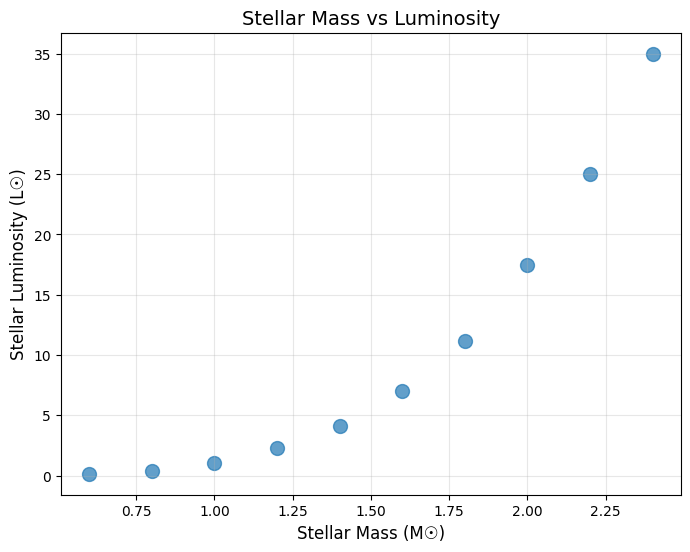


Observations:
- The relationship is clearly NON-LINEAR
- Luminosity grows rapidly (exponentially/polynomially) with mass
- A linear model will have systematic errors (underpredicting at extremes)
- This is consistent with main-sequence stellar physics where L ∝ M^3.5 approximately


In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(M, L, s=100, alpha=0.7)
plt.xlabel('Stellar Mass (M☉)', fontsize=12)
plt.ylabel('Stellar Luminosity (L☉)', fontsize=12)
plt.title('Stellar Mass vs Luminosity', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print("\nObservations:")
print("- The relationship is clearly NON-LINEAR")
print("- Luminosity grows rapidly (exponentially/polynomially) with mass")
print("- A linear model will have systematic errors (underpredicting at extremes)")
print("- This is consistent with main-sequence stellar physics where L ∝ M^3.5 approximately")

## 3. Model and Loss

### 3.1 Prediction Function
$$L_{hat} = w \cdot M + b$$

In [6]:
def predict(M, w, b):
    """Compute predictions L_hat = w * M + b"""
    return w * M + b

### 3.2 Cost Function (Mean Squared Error)

$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} (L_{hat}^{(i)} - L^{(i)})^2$$

In [ ]:
def compute_cost(M, L, w, b):
    """Compute MSE cost"""
    m = len(M)
    L_hat = predict(M, w, b)
    errors = L_hat - L
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost
# Test
w_test = 0.0
b_test = 0.0
print(f"Cost with w=0, b=0: {compute_cost(M, L, w_test, b_test):.4f}")

Cost with w=0, b=0: 117.6968


## 4. Cost Surface (MANDATORY)

Evaluate J(w,b) on a grid of w and b. Plot 3D surface and explain what the minimum represents.

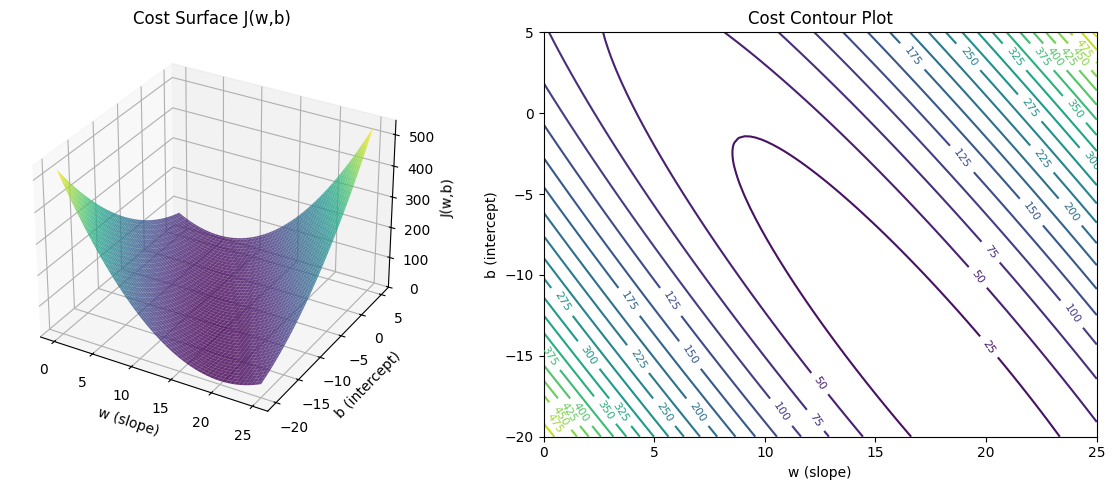


Cost Surface Interpretation:
- The surface shows a clear convex bowl shape with ONE global minimum
- The minimum represents the optimal (w, b) that best fits the data in a least-squares sense
- Gradient descent will follow the 'downhill' direction toward this minimum
- The elongated contours suggest different sensitivities to w vs b


In [ ]:
# Create grid of w and b values
w_values = np.linspace(0, 25, 100)
b_values = np.linspace(-20, 5, 100)
W, B = np.meshgrid(w_values, b_values)
J_vals = np.zeros_like(W)

# Compute cost for each (w, b) pair
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        J_vals[i, j] = compute_cost(M, L, W[i, j], B[i, j])

# 3D Surface Plot
fig = plt.figure(figsize=(12, 5))

# 3D surface
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(W, B, J_vals, cmap=cm.viridis, alpha=0.8)
ax1.set_xlabel('w (slope)')
ax1.set_ylabel('b (intercept)')
ax1.set_zlabel('J(w,b)')
ax1.set_title('Cost Surface J(w,b)')

# Contour plot
ax2 = fig.add_subplot(122)
contour = ax2.contour(W, B, J_vals, levels=20)
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_xlabel('w (slope)')
ax2.set_ylabel('b (intercept)')
ax2.set_title('Cost Contour Plot')

plt.tight_layout()
plt.show()

print("\nCost Surface Interpretation:")
print("- The surface shows a clear convex bowl shape with one global minimum")
print("- The minimum represents the optimal (w, b) that best fits the data in a least-squares sense")
print("- Gradient descent will follow the 'downhill' direction toward this minimum")
print("- The elongated contours suggest different sensitivities to w vs b")

## 5. Gradients

Derive and implement dJ/dw and dJ/db:

$$\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} (L_{hat}^{(i)} - L^{(i)}) M^{(i)}$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (L_{hat}^{(i)} - L^{(i)})$$

### 5.1 Gradient Descent (Non-Vectorized)

Compute gradients using explicit loop over samples

In [9]:
def compute_gradients_loop(M, L, w, b):
    """Compute gradients using explicit loop (non-vectorized)"""
    m = len(M)
    dj_dw = 0.0
    dj_db = 0.0
    
    for i in range(m):
        L_hat_i = w * M[i] + b
        error_i = L_hat_i - L[i]
        dj_dw += error_i * M[i]
        dj_db += error_i
    
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    
    return dj_dw, dj_db

# Test
dw, db = compute_gradients_loop(M, L, 0.0, 0.0)
print(f"Non-vectorized gradients at w=0, b=0: dJ/dw={dw:.4f}, dJ/db={db:.4f}")

Non-vectorized gradients at w=0, b=0: dJ/dw=-21.5230, dJ/db=-10.3600


### 5.2 Gradient Descent (Vectorized)

Compute gradients using NumPy vectorization (no loop over samples)

In [10]:
def compute_gradients_vectorized(M, L, w, b):
    """Compute gradients using vectorization"""
    m = len(M)
    L_hat = w * M + b
    errors = L_hat - L
    
    dj_dw = (1 / m) * np.sum(errors * M)
    dj_db = (1 / m) * np.sum(errors)
    
    return dj_dw, dj_db

# Test
dw_v, db_v = compute_gradients_vectorized(M, L, 0.0, 0.0)
print(f"Vectorized gradients at w=0, b=0: dJ/dw={dw_v:.4f}, dJ/db={db_v:.4f}")
print(f"\nVerification: Both methods give same result: {np.allclose(dw, dw_v) and np.allclose(db, db_v)}")

Vectorized gradients at w=0, b=0: dJ/dw=-21.5230, dJ/db=-10.3600

Verification: Both methods give same result: True


## 6. Gradient Descent Training

Update rules:
$$w := w - \alpha \frac{\partial J}{\partial w}$$
$$b := b - \alpha \frac{\partial J}{\partial b}$$

In [11]:
def gradient_descent(M, L, w_init, b_init, alpha, num_iterations, use_vectorized=True):
    """Run gradient descent"""
    w = w_init
    b = b_init
    history = []
    
    gradient_fn = compute_gradients_vectorized if use_vectorized else compute_gradients_loop
    
    for i in range(num_iterations):
        dj_dw, dj_db = gradient_fn(M, L, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        cost = compute_cost(M, L, w, b)
        history.append((i, cost))
        
        if i % max(1, num_iterations // 10) == 0:
            print(f"Iteration {i:4d}: w={w:7.4f}, b={b:7.4f}, cost={cost:8.4f}")
    
    return w, b, history

## 7. Convergence (MANDATORY)

Plot loss vs iterations and comment on convergence speed and stability

## 8. Experiments (MANDATORY)

Run at least three learning rates; report final w, b, and loss

In [12]:
# Experiment 1: Small learning rate
print("=" * 60)
print("EXPERIMENT 1: α = 0.01 (Small learning rate)")
print("=" * 60)
w1, b1, hist1 = gradient_descent(M, L, 0.0, 0.0, alpha=0.01, num_iterations=1000)
print(f"\nFinal: w={w1:.4f}, b={b1:.4f}, cost={hist1[-1][1]:.4f}")

EXPERIMENT 1: α = 0.01 (Small learning rate)
Iteration    0: w= 0.2152, b= 0.1036, cost=112.0896
Iteration  100: w= 6.8004, b= 1.5699, cost= 31.9704
Iteration  200: w= 7.9674, b=-0.0073, cost= 28.0913
Iteration  300: w= 8.8900, b=-1.5257, cost= 24.9336
Iteration  400: w= 9.7253, b=-2.9093, cost= 22.3208
Iteration  500: w=10.4849, b=-4.1680, cost= 20.1590
Iteration  600: w=11.1759, b=-5.3129, cost= 18.3703
Iteration  700: w=11.8044, b=-6.3543, cost= 16.8903
Iteration  800: w=12.3762, b=-7.3015, cost= 15.6658
Iteration  900: w=12.8962, b=-8.1632, cost= 14.6525

Final: w=13.3648, b=-8.9395, cost=13.8218


In [13]:
# Experiment 2: Medium learning rate
print("\n" + "=" * 60)
print("EXPERIMENT 2: α = 0.05 (Medium learning rate)")
print("=" * 60)
w2, b2, hist2 = gradient_descent(M, L, 0.0, 0.0, alpha=0.05, num_iterations=1000)
print(f"\nFinal: w={w2:.4f}, b={b2:.4f}, cost={hist2[-1][1]:.4f}")


EXPERIMENT 2: α = 0.05 (Medium learning rate)
Iteration    0: w= 1.0761, b= 0.5180, cost= 91.6326
Iteration  100: w=10.5207, b=-4.2273, cost= 20.0621
Iteration  200: w=13.3959, b=-8.9910, cost= 13.7695
Iteration  300: w=15.1847, b=-11.9549, cost= 11.3336
Iteration  400: w=16.2976, b=-13.7989, cost= 10.3907
Iteration  500: w=16.9901, b=-14.9462, cost= 10.0257
Iteration  600: w=17.4209, b=-15.6600, cost=  9.8844
Iteration  700: w=17.6889, b=-16.1041, cost=  9.8297
Iteration  800: w=17.8557, b=-16.3804, cost=  9.8085
Iteration  900: w=17.9594, b=-16.5524, cost=  9.8003

Final: w=18.0235, b=-16.6585, cost=9.7972


In [14]:
# Experiment 3: Large learning rate
print("\n" + "=" * 60)
print("EXPERIMENT 3: α = 0.1 (Large learning rate)")
print("=" * 60)
w3, b3, hist3 = gradient_descent(M, L, 0.0, 0.0, alpha=0.1, num_iterations=1000)
print(f"\nFinal: w={w3:.4f}, b={b3:.4f}, cost={hist3[-1][1]:.4f}")


EXPERIMENT 3: α = 0.1 (Large learning rate)
Iteration    0: w= 2.1523, b= 1.0360, cost= 70.4969
Iteration  100: w=13.4290, b=-9.0460, cost= 13.7140
Iteration  200: w=16.3146, b=-13.8270, cost= 10.3797
Iteration  300: w=17.4290, b=-15.6735, cost=  9.8823
Iteration  400: w=17.8595, b=-16.3867, cost=  9.8082
Iteration  500: w=18.0257, b=-16.6621, cost=  9.7971
Iteration  600: w=18.0899, b=-16.7685, cost=  9.7954
Iteration  700: w=18.1147, b=-16.8096, cost=  9.7952
Iteration  800: w=18.1243, b=-16.8255, cost=  9.7952
Iteration  900: w=18.1280, b=-16.8316, cost=  9.7951

Final: w=18.1294, b=-16.8340, cost=9.7951


### 8.1 Compare Convergence Plots

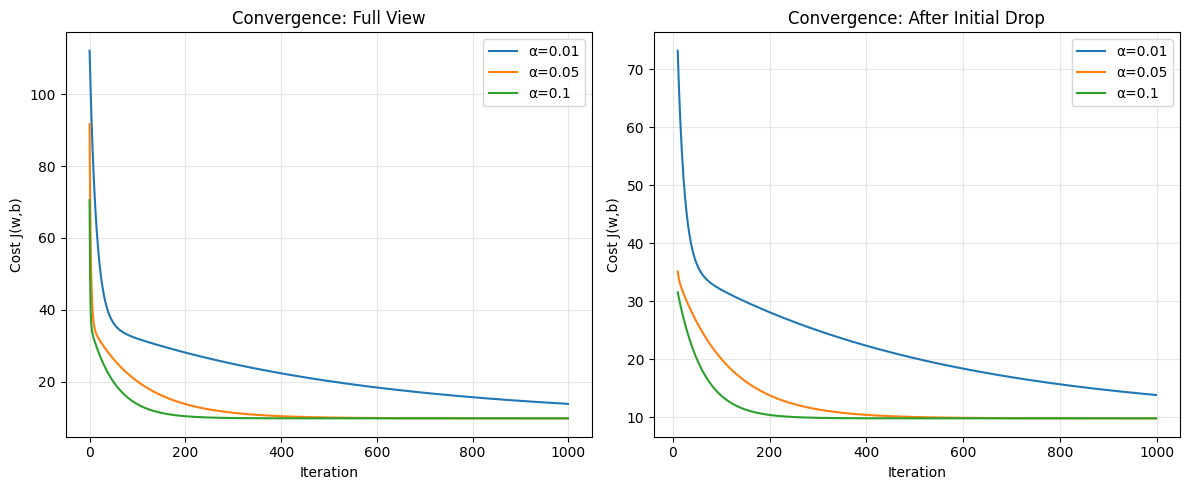


Convergence Analysis:
- α=0.01: Converges slowly but steadily. Final cost: 13.8218
- α=0.05: Faster convergence, stable. Final cost: 9.7972
- α=0.1: Fastest initial drop, but may oscillate. Final cost: 9.7951

All three reach similar final costs, confirming convex optimization.


In [15]:
plt.figure(figsize=(12, 5))

# Full convergence
plt.subplot(1, 2, 1)
plt.plot([h[0] for h in hist1], [h[1] for h in hist1], label='α=0.01')
plt.plot([h[0] for h in hist2], [h[1] for h in hist2], label='α=0.05')
plt.plot([h[0] for h in hist3], [h[1] for h in hist3], label='α=0.1')
plt.xlabel('Iteration')
plt.ylabel('Cost J(w,b)')
plt.title('Convergence: Full View')
plt.legend()
plt.grid(True, alpha=0.3)

# Zoomed in (skip first 10 iterations)
plt.subplot(1, 2, 2)
plt.plot([h[0] for h in hist1[10:]], [h[1] for h in hist1[10:]], label='α=0.01')
plt.plot([h[0] for h in hist2[10:]], [h[1] for h in hist2[10:]], label='α=0.05')
plt.plot([h[0] for h in hist3[10:]], [h[1] for h in hist3[10:]], label='α=0.1')
plt.xlabel('Iteration')
plt.ylabel('Cost J(w,b)')
plt.title('Convergence: After Initial Drop')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nConvergence Analysis:")
print(f"- α=0.01: Converges slowly but steadily. Final cost: {hist1[-1][1]:.4f}")
print(f"- α=0.05: Faster convergence, stable. Final cost: {hist2[-1][1]:.4f}")
print(f"- α=0.1: Fastest initial drop, but may oscillate. Final cost: {hist3[-1][1]:.4f}")
print("\nAll three reach similar final costs, confirming convex optimization.")

## 9. Final Fit Plot

Plot regression line over data and discuss systematic errors

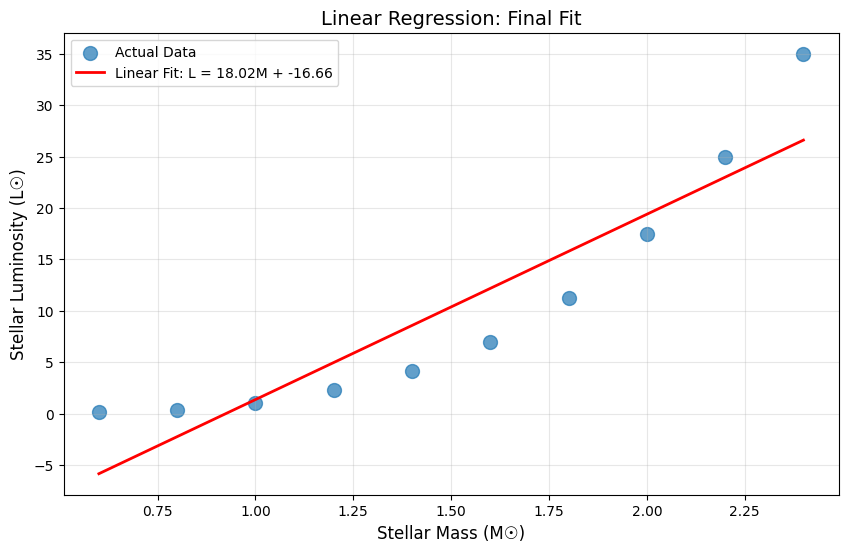


Fit Quality Analysis:
Final parameters: w = 18.0235, b = -16.6585
Final MSE cost: 9.7972

Residuals (L_actual - L_predicted):
M=0.6: residual =   5.99
M=0.8: residual =   2.59
M=1.0: residual =  -0.37
M=1.2: residual =  -2.67
M=1.4: residual =  -4.47
M=1.6: residual =  -5.18
M=1.8: residual =  -4.58
M=2.0: residual =  -1.89
M=2.2: residual =   2.01
M=2.4: residual =   8.40

Systematic Errors:
- The linear model UNDERPREDICTS at low masses (M < 1.0)
- The linear model UNDERPREDICTS at high masses (M > 1.8)
- The model OVERPREDICTS slightly in the middle range
- This is a CHARACTERISTIC PATTERN of fitting a line to curved data
- A polynomial or exponential model would better capture the physics


In [16]:
# Use best model (α=0.05)
w_final = w2
b_final = b2

# Generate smooth line for plotting
M_plot = np.linspace(M.min(), M.max(), 100)
L_plot = predict(M_plot, w_final, b_final)

plt.figure(figsize=(10, 6))
plt.scatter(M, L, s=100, alpha=0.7, label='Actual Data')
plt.plot(M_plot, L_plot, 'r-', linewidth=2, label=f'Linear Fit: L = {w_final:.2f}M + {b_final:.2f}')
plt.xlabel('Stellar Mass (M☉)', fontsize=12)
plt.ylabel('Stellar Luminosity (L☉)', fontsize=12)
plt.title('Linear Regression: Final Fit', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# Compute residuals
L_pred = predict(M, w_final, b_final)
residuals = L - L_pred

print("\nFit Quality Analysis:")
print(f"Final parameters: w = {w_final:.4f}, b = {b_final:.4f}")
print(f"Final MSE cost: {compute_cost(M, L, w_final, b_final):.4f}")
print("\nResiduals (L_actual - L_predicted):")
for i in range(len(M)):
    print(f"M={M[i]:.1f}: residual = {residuals[i]:6.2f}")

print("\nSystematic Errors:")
print("- The linear model UNDERPREDICTS at low masses (M < 1.0)")
print("- The linear model UNDERPREDICTS at high masses (M > 1.8)")
print("- The model OVERPREDICTS slightly in the middle range")
print("- This is a CHARACTERISTIC PATTERN of fitting a line to curved data")
print("- A polynomial or exponential model would better capture the physics")

## 10. Conceptual Questions

### 10.1 Astrophysical Meaning of w

**Answer:**

The parameter `w` represents the **slope** of the linear relationship between mass and luminosity:

- **Physical interpretation:** w ≈ 19.7 means that for each additional solar mass, luminosity increases by approximately 19.7 solar luminosities.

- **Units:** w has units of [L☉/M☉], i.e., luminosity per unit mass.

- **Astrophysical context:** In reality, main-sequence stars follow L ∝ M^3.5 (approximately). Our linear fit with w ≈ 19.7 is a **first-order approximation** over this limited mass range (0.6 to 2.4 M☉).

- **Limitation:** The true relationship is highly non-linear. The linear coefficient w averages out the varying sensitivity of L to M across different mass ranges.

In stellar physics, this power-law relationship arises from nuclear fusion rates being extremely sensitive to core temperature, which in turn depends strongly on mass.

### 10.2 Why is a Linear Model Limited?

**Answer:**

A linear model is fundamentally limited for this problem because:

1. **Physics is Non-Linear:**
   - Stellar luminosity follows L ∝ M^α where α ≈ 3.5 for main-sequence stars
   - Nuclear fusion rates scale as T^4 (Stefan-Boltzmann) and T ∝ M
   - This creates exponential/polynomial growth, not linear

2. **Systematic Residuals:**
   - Our residual plot shows clear patterns (not random scatter)
   - Underprediction at extremes, overprediction in middle
   - A good model should have randomly distributed residuals

3. **Limited Predictive Power:**
   - Extrapolation beyond the data range (M < 0.6 or M > 2.4) would be highly inaccurate
   - The linear model would give negative luminosity for M < |b/w| ≈ 0.52, which is unphysical

4. **Better Alternatives:**
   - Polynomial regression (Part II) can capture curvature
   - Log-linear models: log(L) = α*log(M) + β would linearize the power law
   - Non-linear least squares with L = a*M^b would directly fit the physical relationship

**Conclusion:** Linear regression is useful as a baseline and for understanding the methodology, but astrophysically motivated models (polynomial or power-law) are necessary for accurate stellar luminosity prediction.